# PID tuning classifier — interactive walkthrough

This notebook mirrors **Phase C** (`ml/train_tuning_classifier.py`): load `ml/data/tuning_runs.csv`, train baselines + Random Forest, plot class balance, confusion matrix, and feature importances.

**Working directory:** start Jupyter from the **repository root** (`ecu-simulation-dashboard/`), or adjust `ROOT` in the next cell so it points at that folder.

### Optional: notebook dependencies

Uncomment if `pandas` / `matplotlib` are missing in your environment.

In [1]:
# %pip install pandas matplotlib -q

In [1]:
from pathlib import Path
import os
import sys

ROOT = Path(os.getcwd()).resolve()
if not (ROOT / "backend").is_dir():
    ROOT = ROOT.parent
if not (ROOT / "backend").is_dir():
    raise RuntimeError(
        "Could not find project root (folder with backend/). "
        "Start Jupyter from the ecu-simulation-dashboard directory, or set ROOT manually."
    )
sys.path.insert(0, str(ROOT))
print("ROOT =", ROOT)

ROOT = C:\Users\Hp\ecu-simulation-dashboard


## Load data and class balance

In [2]:
import pandas as pd

DATA = ROOT / "ml/data/tuning_runs.csv"
df = pd.read_csv(DATA)
df.head()

,run_id,seed,kp,ki,kd,target_speed_m_s,dt_s,steps,noise_sigma,overshoot_m_s,settling_time_s,steady_state_error_m_s,mean_abs_error_m_s,duration_s,sample_count,tolerance_m_s,target_ref_m_s,overshoot_ratio,ss_err_ratio,label
0,1,42,0.803369,0.008754,0.055006,21.696322,0.1,300,0.0,0.000000,6.5,0.030196,2.366141,29.9,300,0.500000,21.696322,0.000000,0.060392,no_change
1,2,42,0.910118,0.236845,0.178436,17.608165,0.1,300,0.0,0.115025,5.3,0.000415,1.554903,29.9,300,0.500000,17.608165,0.230049,0.000830,no_change
2,3,42,0.564114,0.010429,0.043728,30.160659,0.1,300,0.0,0.000000,9.3,0.072698,4.625355,29.9,300,0.603213,30.160659,0.000000,0.120518,no_change
3,4,42,0.129190,0.069593,0.129977,31.348244,0.1,300,0.0,3.376055,24.2,0.067680,5.985142,29.9,300,0.626965,31.348244,5.384759,0.107948,reduce_kp
4,5,42,0.342485,0.206243,0.161886,15.194963,0.1,300,0.0,1.127429,-1.0,1.089949,2.040624,29.9,300,0.500000,15.194963,2.254857,2.179898,increase_ki


In [3]:
df["label"].value_counts().sort_index()

label
increase_ki      14
increase_kp     274
no_change      1076
reduce_ki       412
reduce_kp       224
Name: count, dtype: int64

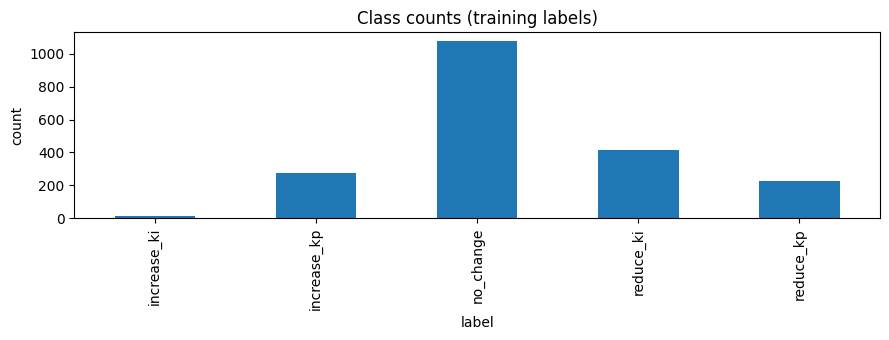

In [4]:
import matplotlib.pyplot as plt

df["label"].value_counts().sort_index().plot(kind="bar", title="Class counts (training labels)", figsize=(9, 3.5))
plt.ylabel("count")
plt.tight_layout()
plt.show()

## Train & evaluate (same logic as `python ml/train_tuning_classifier.py`)

Sets `save_artifacts=True` to refresh `ml/artifacts/` (joblib + metrics.json). Use `save_artifacts=False` for quick plots only.

In [5]:
from ml.train_tuning_classifier import train_and_save

result = train_and_save(
    DATA,
    ROOT / "ml/artifacts",
    test_size=0.2,
    seed=42,
    save_artifacts=True,
)
m = result["metrics"]
print("Rule replay (full CSV):     ", m["rule_replay_accuracy_full"])
print("Val acc — majority baseline:", m["baseline_majority_val_accuracy"])
print("Val acc — logistic:        ", m["logistic_val_accuracy"])
print("Val acc — random forest:   ", m["random_forest_val_accuracy"])

Rule replay (full CSV):      0.9925
Val acc — majority baseline: 0.5375
Val acc — logistic:         0.9375
Val acc — random forest:    0.995


## Confusion matrix (validation, Random Forest)

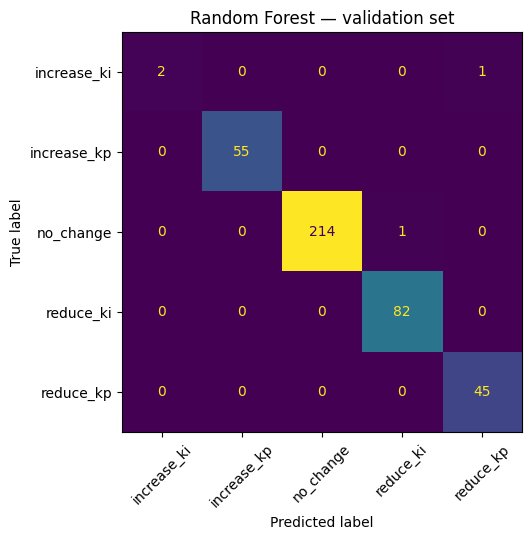

In [6]:
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ConfusionMatrixDisplay(
    confusion_matrix=np.asarray(result["confusion_matrix"]),
    display_labels=result["labels_sorted"],
).plot(ax=ax, xticks_rotation=45, colorbar=False)
ax.set_title("Random Forest — validation set")
plt.tight_layout()
plt.show()

## Random Forest feature importances

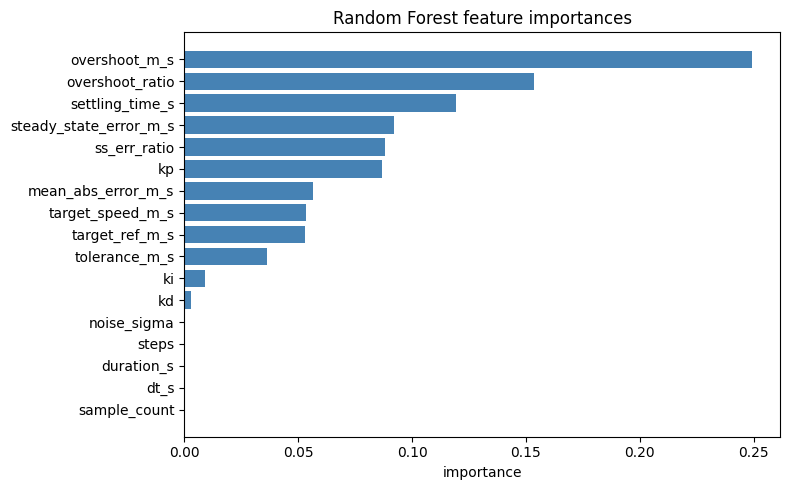

In [7]:
from ml.train_tuning_classifier import FEATURE_COLS

imp = result["feature_importances"]
order = np.argsort(-imp)
plt.figure(figsize=(8, 5))
plt.barh([FEATURE_COLS[i] for i in order[::-1]], imp[order[::-1]], color="steelblue")
plt.xlabel("importance")
plt.title("Random Forest feature importances")
plt.tight_layout()
plt.show()

Per-class precision/recall (validation) are in `m["classification_report_val_rf"]` and in `ml/artifacts/metrics.json` after training.